## K-Nearest Neighbors (KNN) 
**K-Nearest Neighbors (KNN)** is a **non-parametric, instance-based (lazy) learning algorithm** used for:

* **Classification**
* **Regression**

It makes predictions based on **similarity (distance)** between data points.


## 2. Core Idea

KNN works on a very simple principle:

> “Similar data points exist close to each other.”

When a new data point arrives:

1. Calculate distance from all training points
2. Select the **K nearest neighbors**
3. Make prediction based on those neighbors


## 3.  Distance Metrics

KNN relies heavily on distance calculation.

### Common distance functions:

### ➤ Euclidean Distance (most common)

$$ d(x,y)=i=1∑n​(xi​−yi​)2 $$

### ➤ Manhattan Distance

$$
d(x,y) = \sum_{i=1}^{n} |x_i - y_i|
$$

### ➤ Minkowski Distance (generalized form)

$$d(x,y) = \left(\sum_{i=1}^{n} |x_i - y_i|^p \right)^{1/p}
$$


## 4.  Algorithm Steps

### For Classification:

1. Choose value of **K**
2. Compute distance between test point and all training points
3. Select **K nearest neighbors**
4. Assign the **majority class**

### For Regression:

* Take the **average (or weighted average)** of K neighbors


## 5. Choosing K Value

* **Small K (e.g., 1)**
  → High variance (overfitting)

* **Large K**
  → High bias (underfitting)

**Best practice:**

* Use **cross-validation**
* Try odd values (to avoid ties)

## 6. Decision Boundary

* KNN creates **non-linear decision boundaries**
* Very flexible → can model complex patterns


## 7. Key Characteristics

| Property      | Description                       |
| ------------- | --------------------------------- |
| Learning Type | Lazy learning (no training phase) |
| Model Type    | Non-parametric                    |
| Complexity    | High at prediction time           |
| Memory        | Stores entire dataset             |


## 8. Advantages

- Simple and intuitive
- No training phase
- Works well with small datasets
- Can capture complex patterns


## 9. Disadvantages

- Slow for large datasets
- Sensitive to irrelevant features
- Requires feature scaling
- Memory intensive



**Importing Libraries**

In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Dataset
from sklearn.datasets import load_breast_cancer

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.neighbors import KNeighborsClassifier

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Pipeline
from sklearn.pipeline import Pipeline

# Explainability
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Model Saving
import joblib

**Load dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [3]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


In [4]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [5]:
print(data.DESCR[:1000])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

**Exploratory Data Analysis (EDA)**

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
print("\nMissing values:\n", X.isnull().sum())


Missing values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [8]:
print("\nStatistical summary:\n", X.describe())


Statistical summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000           

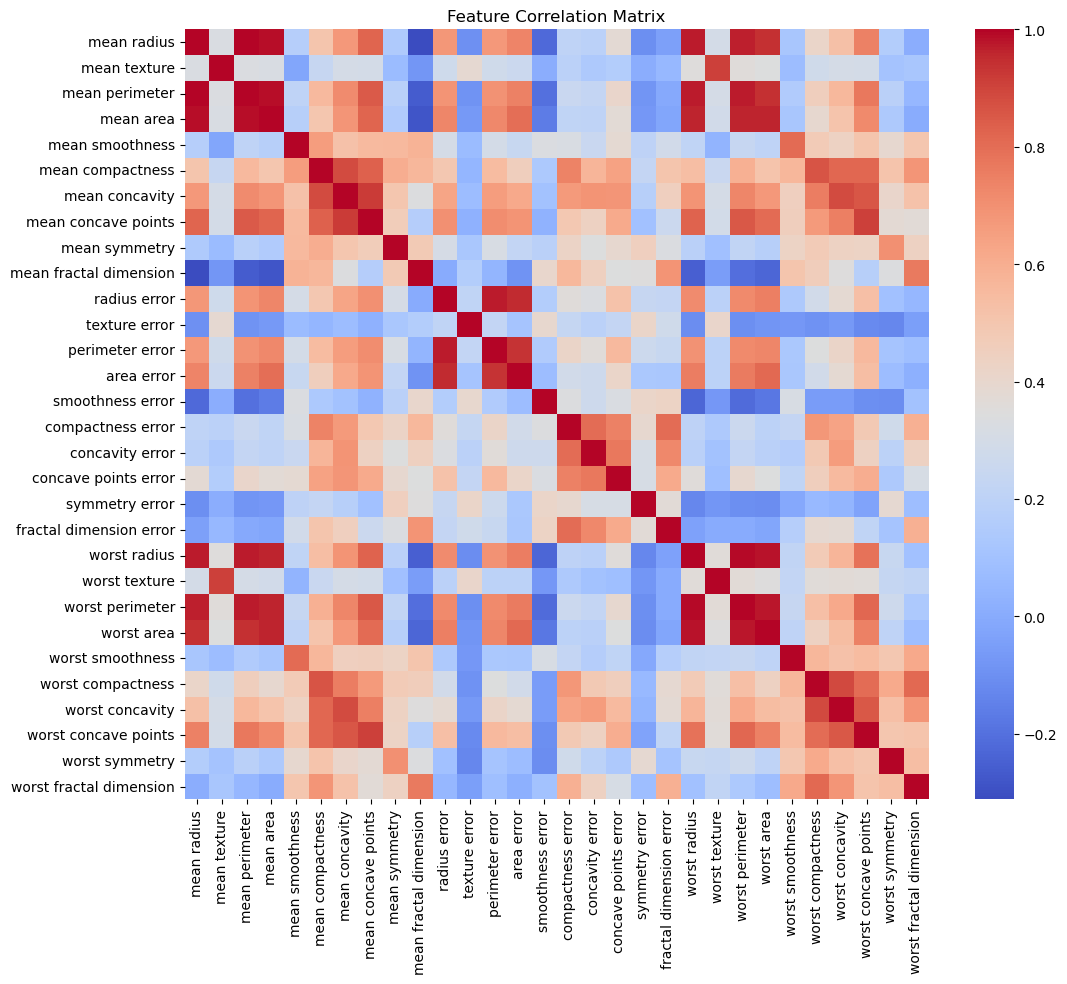

In [9]:
# Correlation Matrix
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

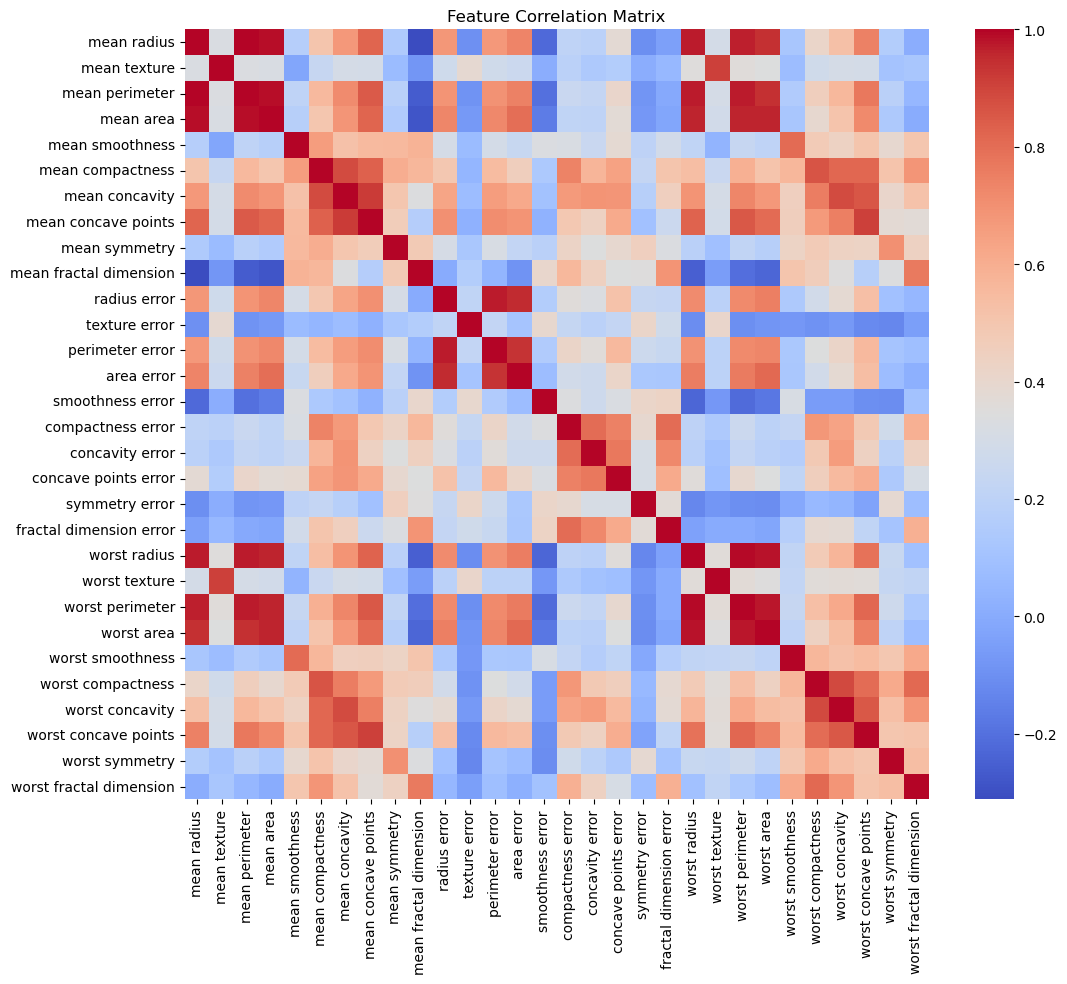

In [10]:
# Distribution Plot
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

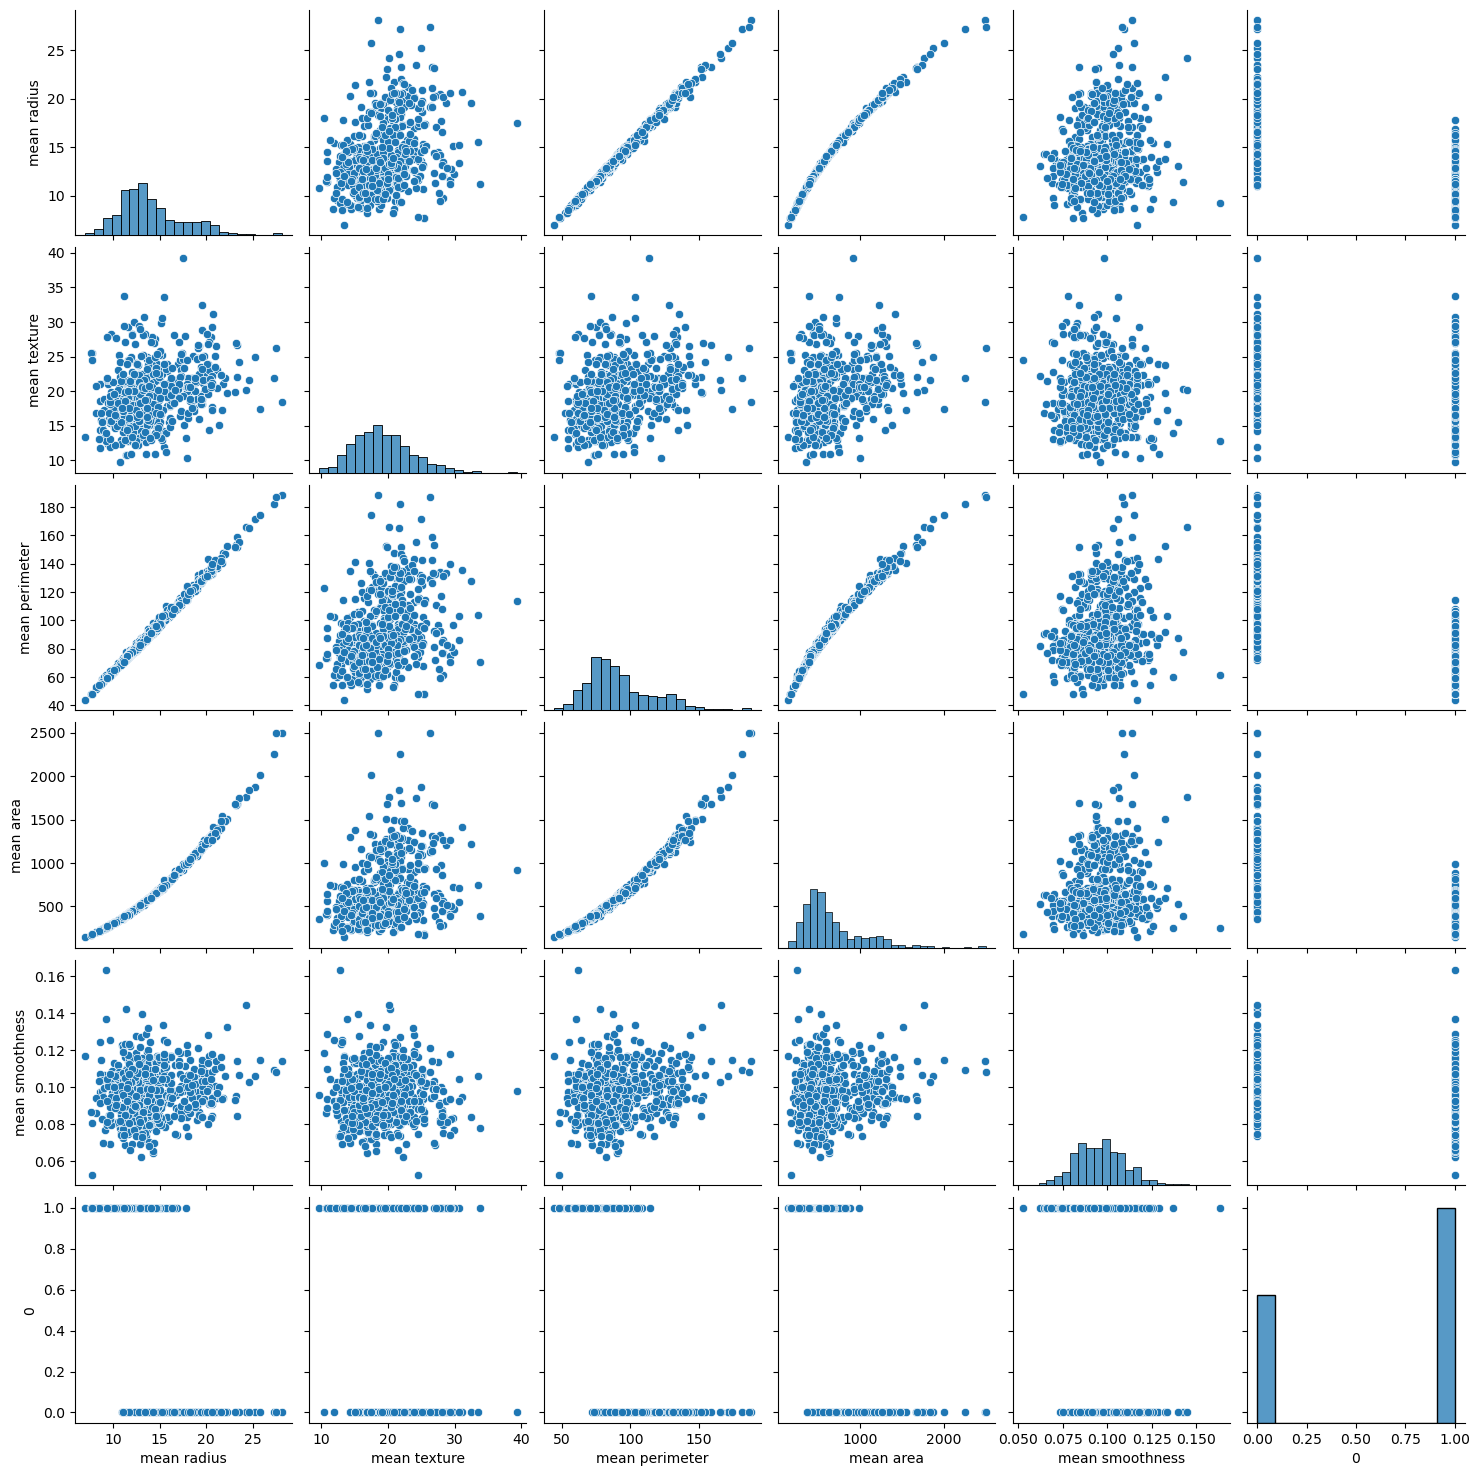

In [11]:
# Pairplot (subset)

sns.pairplot(pd.concat([X.iloc[:, :5], y], axis=1), hue=y.name)

**Data Preprocessing**

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Feature Engineering**

In [13]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_poly = poly.fit_transform(X_scaled)

**Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Machine Learning Pipeline**

In [15]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

**Model Training**

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

**Hyperparameter Tuning with GridSearchCV**

In [17]:
param_grid = {
    'model__n_neighbors': [3,5,7,9,11],
    'model__weights': ['uniform','distance'],
    'model__metric': ['euclidean','manhattan']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'model__metric': ['euclidean', 'manhattan'],
                         'model__n_neighbors': [3, 5, 7, 9, 11],
                         'model__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [18]:
# Best Parameters
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'uniform'}
Best CV Score: 0.9714285714285715


**Model Evaluation**

In [19]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # set your CPU core count

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [20]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("ROC-AUC:", roc_auc_score(y_test,y_prob))

Accuracy: 0.9736842105263158
Precision: 0.96
Recall: 1.0
F1 Score: 0.9795918367346939
ROC-AUC: 0.9884259259259259


In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



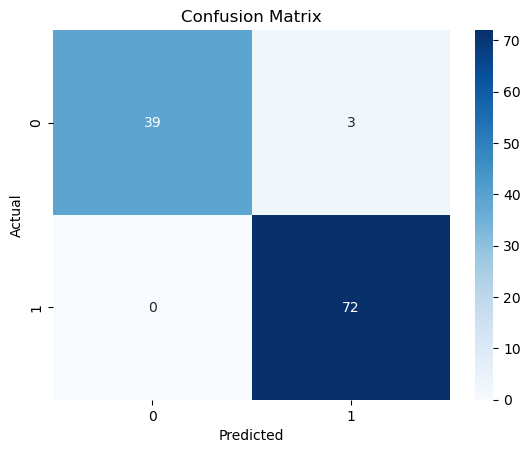

In [22]:
# Classification Report

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**ROC Curve**

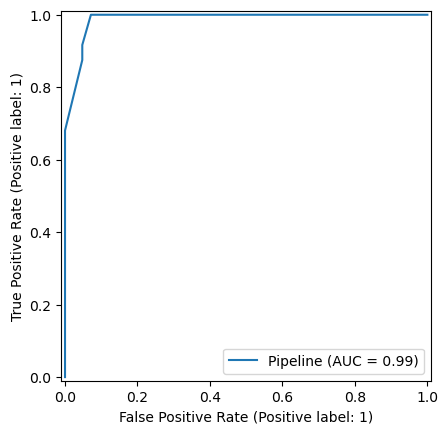

In [23]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

**Precision-Recall Curve**

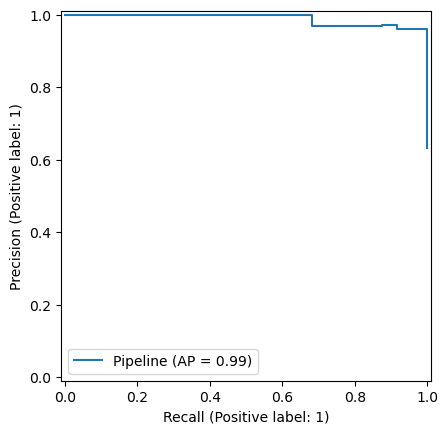

In [24]:
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

**Feature Importance Visualization**

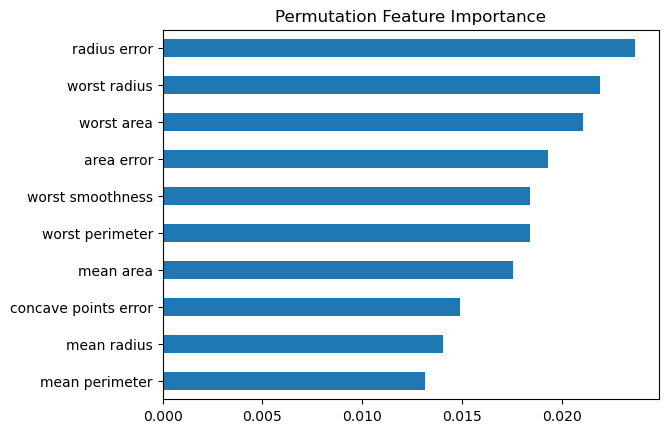

In [25]:
result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(result.importances_mean, index=X.columns)

importance.sort_values().tail(10).plot(kind='barh')
plt.title("Permutation Feature Importance")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

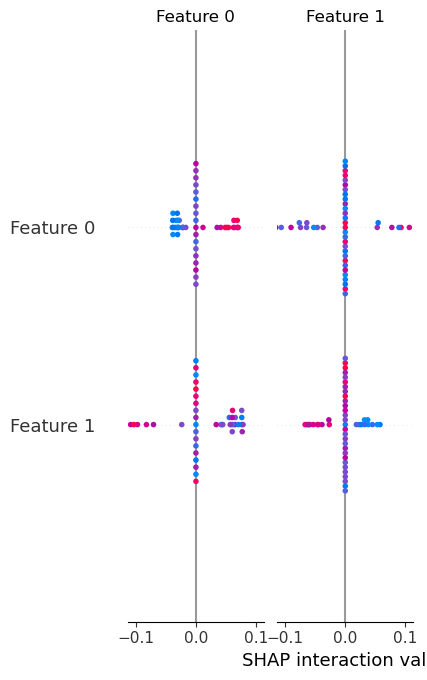

In [26]:
explainer = shap.KernelExplainer(
    best_model.predict_proba,
    shap.sample(X_train, 100)
)

shap_values = explainer.shap_values(X_test[:50])

shap.summary_plot(shap_values, X_test[:50])

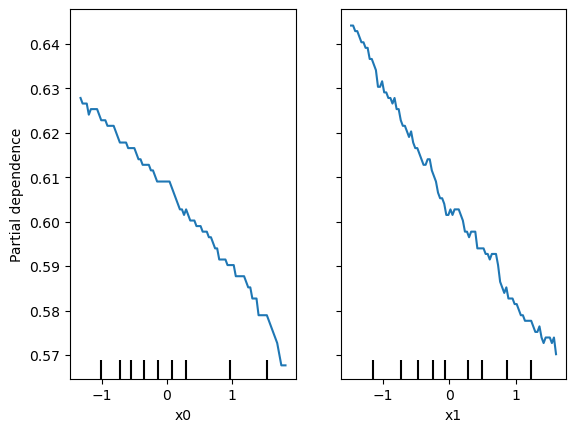

In [27]:
features = [0,1]

PartialDependenceDisplay.from_estimator(
    best_model,
    X_test,
    features
)
plt.show()

**Saving the Model**

In [28]:
joblib.dump(best_model,"knn_classifier_model.pkl")

['knn_classifier_model.pkl']